# Predicting Reference Evapotranspiration Using a Neural Network for Irrigation Planning
Lindsay Kislingbury  
CS 4210 Machine Learning and Its Applications  
Spring 2026

## Introduction

Reference evapotranspiration (ETo) measures how much water evaporates from a reference surface each day. It is the key input to the FAO 56 crop water requirement formula: **ETc = Kc × ETo**, where Kc is a crop-specific coefficient. However, ETo can only be calculated from observed weather data using the Penman-Monteith equation. It cannot be forecasted.

This project trains an LSTM neural network to predict next-day ETo from a sequence of recent weather observations using data from CIMIS Station 44 at UC Riverside (2000–2026). The predicted ETo is then used to compute a daily irrigation recommendation for crops in the Riverside, CA area.

## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pickle

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
# Run this cell to download the project data
!git clone https://github.com/lindsay-kislingbury/eto-forecast.git
%cd eto-forecast

Cloning into 'eto-forecast'...
remote: Enumerating objects: 49, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 49 (delta 19), reused 35 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (49/49), 1.37 MiB | 4.71 MiB/s, done.
Resolving deltas: 100% (19/19), done.
/content/eto-forecast


## Data Loading and Exploration

Daily weather data from CIMIS Station 44 (UC Riverside), January 2000 through April 2026. The dataset contains 9,593 daily records with weather variables including temperature, humidity, solar radiation, wind speed, and reference evapotranspiration (ETo).

In [4]:
df = pd.read_csv('daily.csv')
print("Shape:", df.shape)
print("Date range:", df['Date'].iloc[0], "to", df['Date'].iloc[-1])
print("\nMissing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])
print("\nETo summary statistics:")
print(df['ETo (mm)'].describe())

Shape: (9593, 33)
Date range: 1/1/2000 to 4/6/2026

Missing values per column:
Precip (mm)             22
Sol Rad (W/sq.m)        25
Avg Vap Pres (kPa)      30
Max Air Temp (C)        22
Min Air Temp (C)        91
Avg Air Temp (C)        26
Max Rel Hum (%)         21
Min Rel Hum (%)         21
Avg Rel Hum (%)         75
Dew Point (C)           76
Avg Wind Speed (m/s)    22
Wind Run (km)           23
Avg Soil Temp (C)       20
dtype: int64

ETo summary statistics:
count    9593.000000
mean        4.070967
std         1.935318
min         0.000000
25%         2.450000
50%         4.090000
75%         5.740000
max        10.140000
Name: ETo (mm), dtype: float64


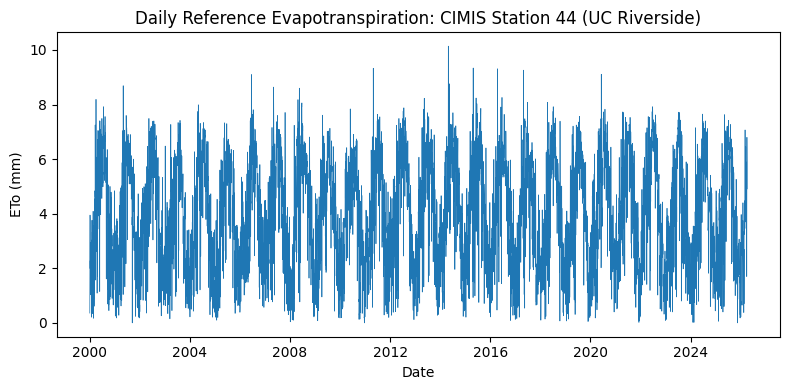

In [5]:
df['Date'] = pd.to_datetime(df['Date'])

plt.figure(figsize=(8, 4))
plt.plot(df['Date'], df['ETo (mm)'], linewidth=0.5)
plt.xlabel('Date')
plt.ylabel('ETo (mm)')
plt.title('Daily Reference Evapotranspiration: CIMIS Station 44 (UC Riverside)')
plt.tight_layout()
plt.show()

## Feature Selection and Preprocessing

Drop metadata columns (station ID, station name, region) and quality control flag columns. Keep 11 weather features, ETo as the target, and precipitation for later use in the irrigation recommendation. Wind Run is excluded because it is redundant with Avg Wind Speed. Missing values (less than 1% of records) are handled with forward fill, which is appropriate for daily weather data that changes gradually. Day of year is added as a feature to capture seasonal patterns in ETo.

In [6]:
# Select feature columns and target
feature_cols = ['Sol Rad (W/sq.m)', 'Avg Vap Pres (kPa)',
                'Max Air Temp (C)', 'Min Air Temp (C)', 'Avg Air Temp (C)',
                'Max Rel Hum (%)', 'Min Rel Hum (%)', 'Avg Rel Hum (%)',
                'Dew Point (C)', 'Avg Wind Speed (m/s)', 'Avg Soil Temp (C)']
target_col = 'ETo (mm)'

# Build clean dataframe with date index
data = df[['Date'] + feature_cols + [target_col, 'Precip (mm)']].copy()
data = data.set_index('Date')

# Forward fill missing values, then back fill any remaining at the start
data = data.ffill().bfill()

# Add day of year for seasonality (1-366)
data['Day of Year'] = data.index.dayofyear

print("Missing values after cleaning:", data.isna().sum().sum())
print("Shape:", data.shape)
print("\nFeatures:", list(data.columns))

Missing values after cleaning: 0
Shape: (9593, 14)

Features: ['Sol Rad (W/sq.m)', 'Avg Vap Pres (kPa)', 'Max Air Temp (C)', 'Min Air Temp (C)', 'Avg Air Temp (C)', 'Max Rel Hum (%)', 'Min Rel Hum (%)', 'Avg Rel Hum (%)', 'Dew Point (C)', 'Avg Wind Speed (m/s)', 'Avg Soil Temp (C)', 'ETo (mm)', 'Precip (mm)', 'Day of Year']


## Chronological Split and Normalization

Split the data chronologically: 2000–2021 for training, 2022–2023 for validation, and 2024–2026 for testing. The split is chronological because this is a time series so we cannot leak future data into training. Features are normalized to [0, 1] using MinMaxScaler fit only on the training set.

In [7]:
# Chronological split
train_data = data[:'2021']
val_data = data['2022':'2023']
test_data = data['2024':]

print("Train: %d rows (%s to %s)" % (len(train_data), train_data.index[0].date(), train_data.index[-1].date()))
print("Val:   %d rows (%s to %s)" % (len(val_data), val_data.index[0].date(), val_data.index[-1].date()))
print("Test:  %d rows (%s to %s)" % (len(test_data), test_data.index[0].date(), test_data.index[-1].date()))

# Columns to normalize (everything except Precip, which we keep raw for irrigation calc)
scale_cols = feature_cols + [target_col, 'Day of Year']

# Fit scaler on training data only
scaler = MinMaxScaler()
scaler.fit(train_data[scale_cols])

# Transform all splits
train_scaled = pd.DataFrame(scaler.transform(train_data[scale_cols]), columns=scale_cols, index=train_data.index)
val_scaled = pd.DataFrame(scaler.transform(val_data[scale_cols]), columns=scale_cols, index=val_data.index)
test_scaled = pd.DataFrame(scaler.transform(test_data[scale_cols]), columns=scale_cols, index=test_data.index)

print("\nScaled training data sample:")
train_scaled.head()

Train: 8036 rows (2000-01-01 to 2021-12-31)
Val:   730 rows (2022-01-01 to 2023-12-31)
Test:  827 rows (2024-01-01 to 2026-04-06)

Scaled training data sample:


,Sol Rad (W/sq.m),Avg Vap Pres (kPa),Max Air Temp (C),Min Air Temp (C),Avg Air Temp (C),Max Rel Hum (%),Min Rel Hum (%),Avg Rel Hum (%),Dew Point (C),Avg Wind Speed (m/s),Avg Soil Temp (C),ETo (mm),Day of Year
Date,,,,,,,,,,,,,
2000-01-01,0.097917,0.296296,0.112861,0.359862,0.354523,0.875000,0.642105,0.780220,0.626536,0.153846,0.226087,0.035503,0.000000
2000-01-02,0.297917,0.222222,0.183727,0.262976,0.344743,0.920455,0.294737,0.593407,0.530713,0.184615,0.217391,0.169625,0.002740
2000-01-03,0.297917,0.148148,0.301837,0.176471,0.383863,0.727273,0.126316,0.307692,0.393120,0.200000,0.200000,0.220907,0.005479
2000-01-04,0.297917,0.148148,0.362205,0.287197,0.435208,0.488636,0.136842,0.252747,0.393120,0.169231,0.200000,0.226824,0.008219
2000-01-05,0.308333,0.111111,0.380577,0.325260,0.486553,0.352273,0.105263,0.142857,0.314496,0.538462,0.200000,0.389546,0.010959


## Sliding Window Sequences for LSTM

Build input sequences for the LSTM. Each sample consists of the previous 14 days of weather features as input and the next day's ETo as the target. A window size of 14 gives the model two full weeks of weather context to predict the next day's evapotranspiration.

In [8]:
SEQ_LEN = 14

# Input features (everything except ETo and Precip)
input_cols = [c for c in scale_cols if c != target_col]

def create_sequences(df_scaled, seq_len):
    X, y = [], []
    values = df_scaled[input_cols].values
    targets = df_scaled[target_col].values
    for i in range(len(df_scaled) - seq_len):
        X.append(values[i:i + seq_len])
        y.append(targets[i + seq_len])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, SEQ_LEN)
X_val, y_val = create_sequences(val_scaled, SEQ_LEN)
X_test, y_test = create_sequences(test_scaled, SEQ_LEN)

print("X_train: %s, y_train: %s" % (X_train.shape, y_train.shape))
print("X_val:   %s, y_val:   %s" % (X_val.shape, y_val.shape))
print("X_test:  %s, y_test:  %s" % (X_test.shape, y_test.shape))
print("\nInput features (%d):" % len(input_cols), input_cols)

X_train: (8022, 14, 12), y_train: (8022,)
X_val:   (716, 14, 12), y_val:   (716,)
X_test:  (813, 14, 12), y_test:  (813,)

Input features (12): ['Sol Rad (W/sq.m)', 'Avg Vap Pres (kPa)', 'Max Air Temp (C)', 'Min Air Temp (C)', 'Avg Air Temp (C)', 'Max Rel Hum (%)', 'Min Rel Hum (%)', 'Avg Rel Hum (%)', 'Dew Point (C)', 'Avg Wind Speed (m/s)', 'Avg Soil Temp (C)', 'Day of Year']


## Dataset and DataLoaders

Custom Dataset wraps the numpy sequences as PyTorch tensors. DataLoaders handle batching and shuffling for training. Validation and test loaders are not shuffled to preserve chronological order.

In [9]:
class EToDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 64

train_dataset = EToDataset(X_train, y_train)
val_dataset = EToDataset(X_val, y_val)
test_dataset = EToDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches: %d, Val batches: %d, Test batches: %d" % (len(train_loader), len(val_loader), len(test_loader)))

Train batches: 126, Val batches: 12, Test batches: 13


## Model Improvement

Baseline (v1): MAE = 0.685 mm/day, RMSE = 0.934 mm/day (seq_len=7, hidden=64, MSELoss, 100 epochs)

Changes for final model:
- Sequence length: 7 → 14 days (more weather context for the model)
- Hidden size: 64 → 128 (more capacity to learn complex patterns)
- Epochs: 100 → 200 with early stopping (train longer without overfitting)
- Added attention mechanism (learns which days in the sequence matter most)
- Loss function: MSELoss → L1Loss (reduces peak smoothing, better for irrigation planning)

Additional experiments that did not improve results: adding past ETo as input (redundant with weather features), bidirectional LSTM (backward context doesn't help for forecasting), and CNN-LSTM hybrid (no benefit for clean tabular data).

Results vary slightly between runs due to random initialization (observed range: 0.636–0.652).

## LSTM Model with Attention

LSTM network with an attention mechanism for next-day ETo prediction. The LSTM processes the 14-day input sequence, and the attention layer learns to weight each time step by its importance for the prediction. This weighted summary is passed through fully connected layers to produce a single ETo prediction. Dropout is applied for regularization.

In [10]:
class EToLSTMAttention(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout)

        # Attention layer
        self.attention = nn.Linear(hidden_size, 1)

        self.fc1 = nn.Linear(hidden_size, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        # LSTM processes the full sequence
        out, (h_n, c_n) = self.lstm(x)

        # Compute attention weights across time steps
        attn_weights = torch.softmax(self.attention(out), dim=1)
        # Weighted sum of LSTM outputs
        out = torch.sum(attn_weights * out, dim=1)

        out = self.relu(self.fc1(out))
        out = self.dropout(out)
        out = self.fc2(out)
        return out.squeeze(1)

# Hyperparameters
INPUT_SIZE = len(input_cols)  # 12 features
HIDDEN_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.2

model = EToLSTMAttention(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)
print(model)

EToLSTMAttention(
  (lstm): LSTM(12, 128, num_layers=2, batch_first=True, dropout=0.2)
  (attention): Linear(in_features=128, out_features=1, bias=True)
  (fc1): Linear(in_features=128, out_features=32, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)


## Training

Train using L1Loss (MAE) and Adam optimizer. L1Loss penalizes all errors equally, which produces better peak predictions than MSELoss for this application. Learning rate is reduced automatically when validation loss plateaus using ReduceLROnPlateau. Early stopping saves the best model and halts training if validation loss does not improve for 15 epochs.

In [11]:
N_EPOCHS = 200
LEARNING_RATE = 0.001

loss_fn = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

train_losses = []
val_losses = []

# early stopping
best_val_loss = float('inf')
patience_counter = 0
EARLY_STOP_PATIENCE = 15

for epoch in range(N_EPOCHS):
    # Training
    model.train(True)
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        train_loss = loss_fn(outputs, y_batch)
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()
        batch_losses.append(float(train_loss.detach()))
    avg_train_loss = np.mean(batch_losses)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    batch_losses = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            val_loss = loss_fn(outputs, y_batch)
            batch_losses.append(float(val_loss))
    avg_val_loss = np.mean(batch_losses)
    val_losses.append(avg_val_loss)

    scheduler.step(avg_val_loss)

    # early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'eto_lstm_best.pth')
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print("Early stopping at epoch %d" % (epoch + 1))
            break

    if (epoch + 1) % 10 == 0:
        print("Epoch: %d, train_loss: %f, val_loss: %f" % (epoch + 1, avg_train_loss, avg_val_loss))

model.load_state_dict(torch.load('eto_lstm_best.pth', weights_only=True))

Epoch: 10, train_loss: 0.087095, val_loss: 0.070797
Epoch: 20, train_loss: 0.073694, val_loss: 0.063649
Epoch: 30, train_loss: 0.072537, val_loss: 0.064752
Epoch: 40, train_loss: 0.071818, val_loss: 0.063059
Early stopping at epoch 49


<All keys matched successfully>

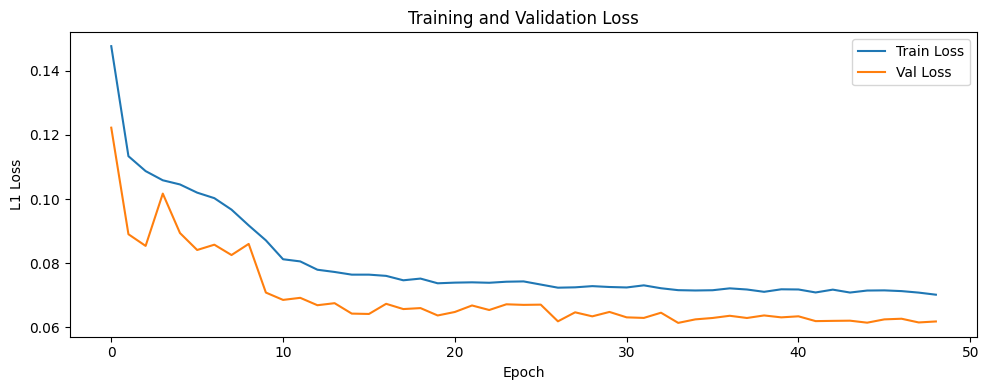

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('L1 Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

## Test Set Evaluation

Evaluate the trained model on the held-out test set (2024–2026). Predictions are inverse-transformed back to mm for interpretable metrics. Performance is measured using MAE (mean absolute error) and RMSE (root mean squared error) in mm/day.

In [13]:
# Get predictions on test set
model.eval()
preds_scaled = []
actuals_scaled = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds_scaled.append(outputs.cpu().numpy())
        actuals_scaled.append(y_batch.numpy())

preds_scaled = np.concatenate(preds_scaled)
actuals_scaled = np.concatenate(actuals_scaled)

# Inverse transform to get mm/day
def inverse_transform_eto(scaled_values):
    dummy = np.zeros((len(scaled_values), len(scale_cols)))
    eto_idx = scale_cols.index(target_col)
    dummy[:, eto_idx] = scaled_values
    return scaler.inverse_transform(dummy)[:, eto_idx]

preds_mm = inverse_transform_eto(preds_scaled)
actuals_mm = inverse_transform_eto(actuals_scaled)

mae = mean_absolute_error(actuals_mm, preds_mm)
rmse = np.sqrt(mean_squared_error(actuals_mm, preds_mm))

print("Test MAE:  %.3f mm/day" % mae)
print("Test RMSE: %.3f mm/day" % rmse)

Test MAE:  0.658 mm/day
Test RMSE: 0.944 mm/day


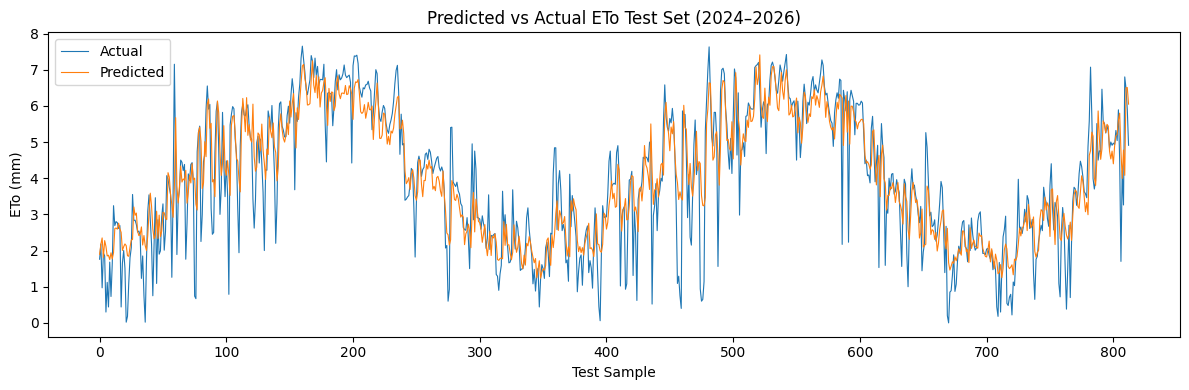

In [14]:
plt.figure(figsize=(12, 4))
plt.plot(actuals_mm, label='Actual', linewidth=0.8)
plt.plot(preds_mm, label='Predicted', linewidth=0.8)
plt.xlabel('Test Sample')
plt.ylabel('ETo (mm)')
plt.title('Predicted vs Actual ETo Test Set (2024–2026)')
plt.legend()
plt.tight_layout()
plt.show()

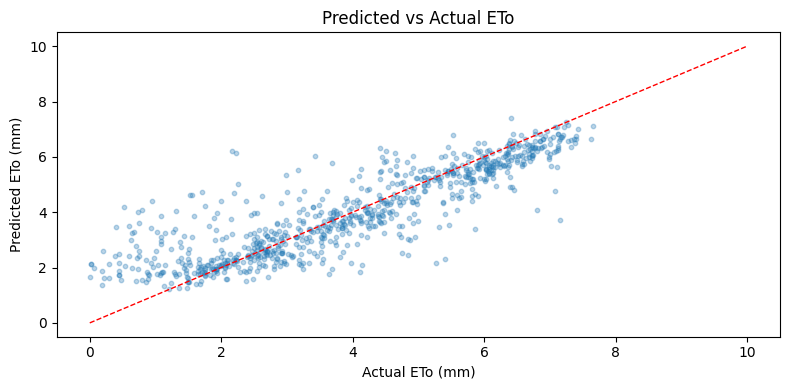

In [15]:
plt.figure(figsize=(8, 4))
plt.scatter(actuals_mm, preds_mm, alpha=0.3, s=10)
plt.plot([0, 10], [0, 10], 'r--', linewidth=1)
plt.xlabel('Actual ETo (mm)')
plt.ylabel('Predicted ETo (mm)')
plt.title('Predicted vs Actual ETo')
plt.tight_layout()
plt.show()

## Irrigation Recommendation

Apply the FAO 56 crop water requirement formula to convert predicted ETo into an irrigation recommendation. Crop evapotranspiration is computed as ETc = Kc × ETo, where Kc is the crop coefficient. Subtracting expected rainfall gives the recommended water application in mm/day. Citrus is used as the example crop (Kc ≈ 0.65 year-round).
The Streamlit app adjusts this value for local climate using FAO 56 Eq. 62

In [16]:
# Crop coefficient for citrus (FAO 56)
Kc_citrus = 0.65

# Use test set predictions to demonstrate the irrigation pipeline
# Get precipitation for the test period (offset by SEQ_LEN to align with predictions)
test_precip = test_data['Precip (mm)'].values[SEQ_LEN:]

# Compute irrigation recommendation
predicted_etc = Kc_citrus * preds_mm
irrigation_mm = np.maximum(predicted_etc - test_precip, 0)

# Show a sample of results
results = pd.DataFrame({
    'Date': test_data.index[SEQ_LEN:],
    'Predicted ETo (mm)': np.round(preds_mm, 2),
    'Predicted ETc (mm)': np.round(predicted_etc, 2),
    'Precip (mm)': test_precip,
    'Irrigation Needed (mm)': np.round(irrigation_mm, 2)
})
print("Sample irrigation recommendations (citrus, Kc=0.65):\n")
print(results.head(14).to_string(index=False))

Sample irrigation recommendations (citrus, Kc=0.65):

      Date  Predicted ETo (mm)  Predicted ETc (mm)  Precip (mm)  Irrigation Needed (mm)
2024-01-15                1.90                1.23          0.0                    1.23
2024-01-16                2.17                1.41          0.0                    1.41
2024-01-17                2.35                1.53          0.0                    1.53
2024-01-18                1.81                1.18          0.0                    1.18
2024-01-19                2.27                1.48          0.0                    1.48
2024-01-20                2.12                1.38          8.7                    0.00
2024-01-21                1.85                1.20          3.9                    0.00
2024-01-22                1.87                1.22         18.2                    0.00
2024-01-23                1.75                1.14          0.2                    0.94
2024-01-24                1.94                1.26          0.0   

## Save Model For Deployment

Save the trained model weights and scaler for use in the Streamlit application.

In [17]:
torch.save(model.state_dict(), 'eto_lstm_model.pth')

with open('eto_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save metadata needed to reconstruct the model and sequences
model_config = {
    'input_size': INPUT_SIZE,
    'hidden_size': HIDDEN_SIZE,
    'num_layers': NUM_LAYERS,
    'dropout': DROPOUT,
    'seq_len': SEQ_LEN,
    'input_cols': input_cols,
    'scale_cols': scale_cols,
    'target_col': target_col,
    # Station 44 long-term climate averages for FAO 56 Eq. 62 Kc adjustment
    'mean_wind_speed': float(train_data['Avg Wind Speed (m/s)'].mean()),
    'mean_rh_min': float(train_data['Min Rel Hum (%)'].mean()),
}

with open('eto_model_config.pkl', 'wb') as f:
    pickle.dump(model_config, f)

print("Saved: eto_lstm_model.pth, eto_scaler.pkl, eto_model_config.pkl")

Saved: eto_lstm_model.pth, eto_scaler.pkl, eto_model_config.pkl
